# Objective 4 — System Evaluation

Evaluate CyREN as a SOC-automation system. Four metrics were scoped; this
notebook computes the **two that the current data fully supports**:

1. **Automation rate** — share of events the system handles automatically
   (high → auto-block, low → auto-log) vs. those routed to a human
   (uncertain → approval queue).
2. **False-positive identification rate** — how well the triage classifier
   (XGBoost, from Objective 3) recognises benign traffic (false positives),
   i.e. the **recall on the benign class**.

The other two (**MTTR**, **MTTD**) need extra timestamp instrumentation and are
handled separately (Event.ingested_at + a live run for MTTR; an Elasticsearch
alert-index query for MTTD).

## Setup
Run from the repo root so `app` imports and `data/cyren.db` resolve (works whether launched from the repo root or from `notebooks/`).

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
# make sure the working dir is the repo root
if not os.path.exists('app') and os.path.exists(os.path.join('..', 'app')):
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 12, 'axes.titlesize': 14, 'figure.autolayout': True})
RANDOM_STATE = 42
print('cwd:', os.getcwd())

cwd: C:\cyren


## 1. Automation rate

Source: the `Event` table. Triage routes every event into one of three tiers:

| risk tier | action | automated? |
|---|---|---|
| `high` | auto-block (iptables) | yes |
| `low` | auto-log | yes |
| `uncertain` | human approval queue | **no** |

`automation rate = (high + low) / total`. `BlockedIP.blocked_by` confirms the
high-tier blocks were made automatically (`auto`).

In [2]:
from app import create_app
from app.models.db import Event, BlockedIP
from collections import Counter

app = create_app()
with app.app_context():
    risk = Counter(e.risk for e in Event.query.all())
    blocked_by = Counter(b.blocked_by for b in BlockedIP.query.all())

total = sum(risk.values())
auto  = risk.get('high', 0) + risk.get('low', 0)
human = risk.get('uncertain', 0)
print(f'total events: {total}')
print(f'BlockedIP.blocked_by: {dict(blocked_by)}  (auto = made without a human)')

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


total events: 159
BlockedIP.blocked_by: {'auto': 42}  (auto = made without a human)


In [3]:
rows = [
    ('Auto-block (high)', risk.get('high', 0), 'automated'),
    ('Auto-log (low)',    risk.get('low', 0),  'automated'),
    ('Human review (uncertain)', risk.get('uncertain', 0), 'manual'),
]
auto_df = pd.DataFrame(rows, columns=['Disposition', 'Events', 'Mode'])
auto_df['Share'] = (auto_df['Events'] / total).round(3)
automation_rate = auto / total
print(f'AUTOMATION RATE = (high+low) {auto} / total {total} = {automation_rate:.1%}')
print(f'human-review rate = {human}/{total} = {human/total:.1%}')
auto_df

AUTOMATION RATE = (high+low) 117 / total 159 = 73.6%
human-review rate = 42/159 = 26.4%


,Disposition,Events,Mode,Share
0,Auto-block (high),62,automated,0.390
1,Auto-log (low),55,automated,0.346
2,Human review (uncertain),42,manual,0.264


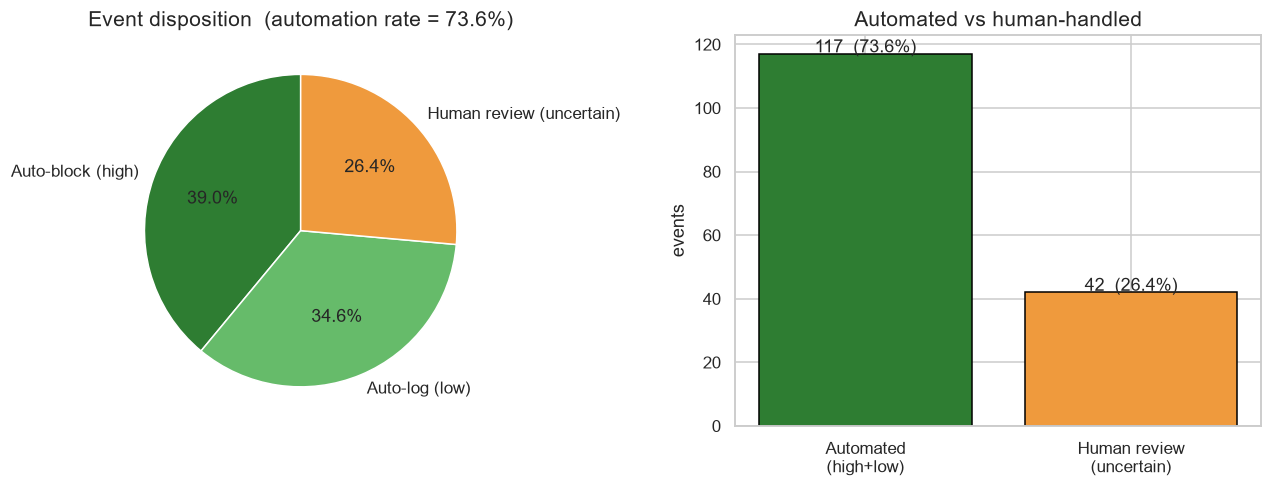

In [4]:
fig, (axp, axb) = plt.subplots(1, 2, figsize=(12, 4.6))
colors = ['#2e7d32', '#66bb6a', '#ef9a3d']
axp.pie(auto_df['Events'], labels=auto_df['Disposition'], autopct='%1.1f%%',
        colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'})
axp.set_title(f'Event disposition  (automation rate = {automation_rate:.1%})')
axb.bar(['Automated\n(high+low)', 'Human review\n(uncertain)'], [auto, human],
        color=['#2e7d32', '#ef9a3d'], edgecolor='black')
axb.set_ylabel('events'); axb.set_title('Automated vs human-handled')
for i, v in enumerate([auto, human]):
    axb.text(i, v + 0.5, f'{v}  ({v/total:.1%})', ha='center')
plt.show()

## 2. False-positive identification rate

The triage classifier's job is to separate **true positives (attacks)** from
**false positives (benign traffic)**. The *false-positive identification rate*
is the classifier's **recall on the benign class** — of all the events that are
actually benign, how many it correctly flags as benign.

We use the deployed model (**XGBoost**) on the same labelled, grey-zone dataset
as Objective 3 (`data/training_set.csv`), with **5-fold cross-validated
predictions** so every sample is scored out-of-fold. `source_ip` is not a
feature (asserted), and the model outputs `confidence`/`risk` are excluded.

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

df = pd.read_csv('data/training_set.csv')
assert 'source_ip' not in df.columns, 'source_ip must never be a feature!'
FEATURES = ['rule_encoded', 'risk_score', 'severity_num', 'has_keyword',
            'request_count', 'duration_seconds', 'request_rate_per_min']
X, y = df[FEATURES], df['label']            # 1 = attack (TP), 0 = benign (FP)
print(f'{len(df)} rows | attack(1)={int((y==1).sum())} benign/FP(0)={int((y==0).sum())}')

skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
xgb = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, subsample=0.9,
                    eval_metric='logloss', random_state=RANDOM_STATE)
y_pred = cross_val_predict(xgb, X, y, cv=skf)   # out-of-fold predictions

103 rows | attack(1)=65 benign/FP(0)=38


In [6]:
# FP class = benign = label 0
fp_recall    = recall_score(y, y_pred, pos_label=0)     # <- the FP identification rate
fp_precision = precision_score(y, y_pred, pos_label=0)
fp_f1        = f1_score(y, y_pred, pos_label=0)
tp_recall    = recall_score(y, y_pred, pos_label=1)
tp_precision = precision_score(y, y_pred, pos_label=1)

metrics = pd.DataFrame({
    'Precision': [fp_precision, tp_precision],
    'Recall':    [fp_recall,    tp_recall],
    'F1-score':  [fp_f1, f1_score(y, y_pred, pos_label=1)],
}, index=['Benign / False-Positive (0)', 'Attack / True-Positive (1)']).round(3)
print(f'FALSE-POSITIVE IDENTIFICATION RATE (benign recall) = {fp_recall:.1%}')
print(f'   benign precision = {fp_precision:.1%}')
metrics

FALSE-POSITIVE IDENTIFICATION RATE (benign recall) = 100.0%
   benign precision = 100.0%


,Precision,Recall,F1-score
Benign / False-Positive (0),1.0,1.0,1.0
Attack / True-Positive (1),1.0,1.0,1.0


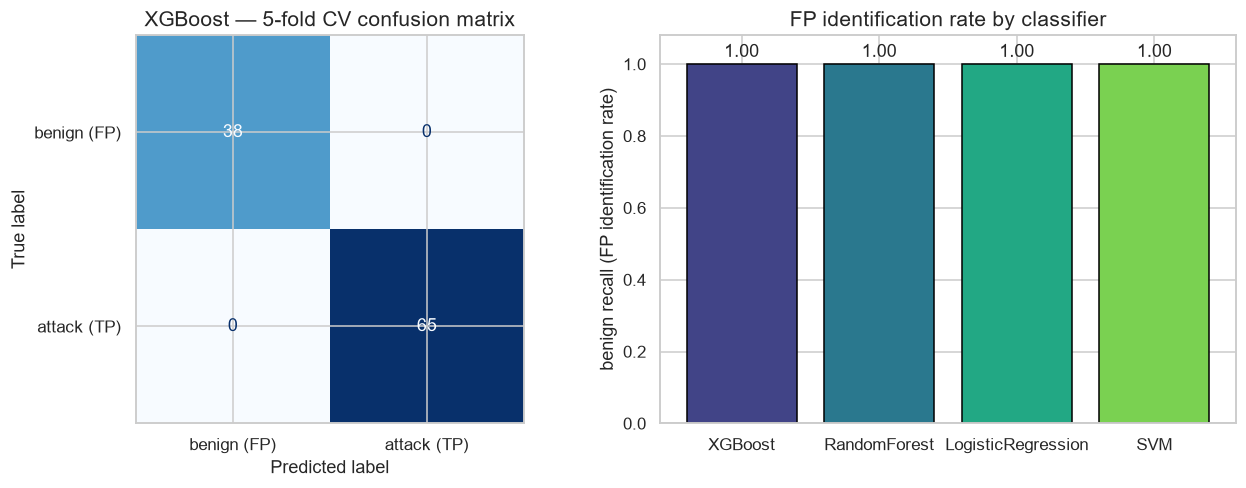

In [7]:
cm = confusion_matrix(y, y_pred, labels=[0, 1])
fig, (axc, axr) = plt.subplots(1, 2, figsize=(12, 4.6))
ConfusionMatrixDisplay(cm, display_labels=['benign (FP)', 'attack (TP)']).plot(ax=axc, cmap='Blues', colorbar=False)
axc.set_title('XGBoost — 5-fold CV confusion matrix')

# benign recall across all four classifiers (deployed = XGBoost)
clfs = {
    'XGBoost': xgb,
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    'SVM': make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=RANDOM_STATE)),
}
fp_rec = {n: recall_score(y, cross_val_predict(m, X, y, cv=skf), pos_label=0) for n, m in clfs.items()}
axr.bar(list(fp_rec.keys()), list(fp_rec.values()), color=sns.color_palette('viridis', 4), edgecolor='black')
axr.set_ylim(0, 1.08); axr.set_ylabel('benign recall (FP identification rate)')
axr.set_title('FP identification rate by classifier')
for i, v in enumerate(fp_rec.values()):
    axr.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.show()

## 3. Summary

| Metric | Value | Source | Status |
|---|---|---|---|
| **Automation rate** | see §1 (~74%) | `Event.risk` / `Event.status` (+ `BlockedIP.blocked_by`) | ✅ computed |
| **FP identification rate** | see §2 (benign recall) | XGBoost on the labelled grey-zone set (5-fold CV) | ✅ computed |
| MTTR | — | `BlockedIP.created_at` − `Event.ingested_at` | ⏳ needs `ingested_at` + a live (non-backfill) run |
| MTTD | — | Kibana alert `@timestamp` − log `@timestamp` | ⏳ needs an Elasticsearch alert-index query |

**Notes.** `blocked_by` is entirely `auto`, confirming high-risk blocks are made
without a human. The FP identification rate is measured with out-of-fold
predictions on the grey-zone dataset (request_count deliberately overlapped), so
the classifier cannot separate the classes on volume — it must recognise benign
traffic from behaviour, and the number reflects that. A near-perfect value
reflects the clean lab separator (see the Objective 3 caveat); the methodology,
not the headline number, is the transferable result.